<a href="https://colab.research.google.com/github/hongocphuongnhu/TH_Deep_Learning/blob/main/Tuan03_THDeep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước dữ liệu gốc:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Kích thước dữ liệu gốc:
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [ ]:
# Reshape dữ liệu thành 2D array
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

# Feature scaling
# dùng MinMaxScaler để đưa giá trị pixel về khoảng [0, 1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes:  10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Khởi tạo mô hình
model = Sequential()

# Thêm hidden layer đầu tiên với hàm kích hoạt ReLU
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm hidden layer thứ hai
model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Thêm output layer với hàm softmax
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Compile neural network với Optimizer Adam và hàm Loss để đánh giá
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Huấn luyện mô hình
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.3279 - loss: 1.8453 - val_accuracy: 0.3706 - val_loss: 1.7843
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3990 - loss: 1.6777 - val_accuracy: 0.3948 - val_loss: 1.7076
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4291 - loss: 1.5959 - val_accuracy: 0.4426 - val_loss: 1.5651
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4442 - loss: 1.5487 - val_accuracy: 0.4302 - val_loss: 1.5749
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.4584 - loss: 1.5070 - val_accuracy: 0.4444 - val_loss: 1.5828
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.4680 - loss: 1.4802 - val_accuracy: 0.4392 - val_loss: 1.5597
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4812 - loss: 1.4502 - val_accuracy: 0.4648 - val_loss: 1.5020
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.4895 -

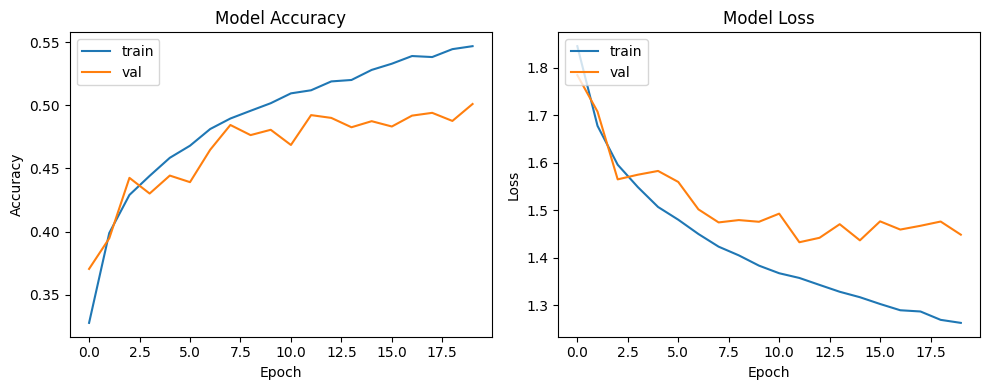

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Nhãn dự đoán: 3
Nhãn thực tế: 3


In [ ]:
# Vẽ biểu đồ Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

# Vẽ biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# Dự báo thử 1 ảnh mới trong tập test
print("Nhãn dự đoán:", np.argmax(model.predict(X_test)[0]))
print("Nhãn thực tế:", y_test[0][0])

In [ ]:
#BÀI 2: MNIST
# Đọc dữ liệu MNIST
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

print('X_train shape:', X_train_mnist.shape)   # (60000, 28, 28)
print('X_test shape :', X_test_mnist.shape)
print('Classes      :', np.unique(y_train_mnist))

In [ ]:
#Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_mnist[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train_mnist[i]}')
    axes[i].axis('off')
plt.suptitle('MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#Tiền xử lý
X_train_mnist_flat = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_mnist_flat  = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0

print('X_train_flat shape:', X_train_mnist_flat.shape)

In [ ]:
#Xây dựng mô hình ANN
mnist_model = Sequential([
    Dense(256, input_dim=784, kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(128, kernel_initializer='uniform', activation='relu'),
    Dense(10,  kernel_initializer='uniform', activation='softmax')
])

mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mnist_model.summary()

In [ ]:
#Huấn luyện MNIST model
mnist_fit = mnist_model.fit(
    X_train_mnist_flat, y_train_mnist,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

In [ ]:
#Đánh giá model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(mnist_fit.history['accuracy'], label='train')
ax1.plot(mnist_fit.history['val_accuracy'], label='val')
ax1.set_title('MNIST Model Accuracy'); ax1.legend()

ax2.plot(mnist_fit.history['loss'], label='train')
ax2.plot(mnist_fit.history['val_loss'], label='val')
ax2.set_title('MNIST Model Loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = mnist_model.evaluate(X_test_mnist_flat, y_test_mnist, verbose=0)
print(f'Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

In [ ]:
#Dự báo (MNIST)
preds_mnist = np.argmax(mnist_model.predict(X_test_mnist_flat[:10]), axis=1)
print('Predicted:', preds_mnist)
print('True     :', y_test_mnist[:10])

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test_mnist[i], cmap='gray')
    color = 'green' if preds_mnist[i] == y_test_mnist[i] else 'red'
    ax.set_title(str(preds_mnist[i]), color=color)
    ax.axis('off')
plt.suptitle('MNIST Predictions (green=correct, red=wrong)')
plt.tight_layout(); plt.show()